# Zomato Bangalore Restaurant Analysis

## Data Collection

This project utilises the **Zomato Bangalore Restaurants Dataset** obtained from Kaggle (Himanshu Poddar).
The dataset captures restaurant-level data scraped from Zomato's platform for the city of Bengaluru —
one of India's most active food-delivery and dining markets.

**Source**: [Kaggle — Zomato Bangalore Restaurants](https://www.kaggle.com/datasets/himanshupoddar/zomato-bangalore-restaurants)

---

## Project Objective

This project analyses **51,717 restaurant records** across Bengaluru to uncover patterns in
ratings, pricing, cuisine popularity, and service adoption — and identify what factors
drive a restaurant's success on the Zomato platform.

---

## Dataset Overview

| Metric           | Value                                      |
|------------------|--------------------------------------------|
| Total Records    | 51,717                                     |
| Total Features   | 17 columns (12 retained after cleaning)    |
| Domain           | Food-Tech & Restaurant Intelligence        |
| Geography        | Bengaluru, Karnataka, India                |
| Data Source      | Zomato (scraped via Kaggle)                |

---

## Key Information Captured

- **Restaurant Identity** — Name, location, and full address across Bengaluru neighbourhoods
- **Service Type** — Whether the restaurant supports online ordering and/or table booking
- **Ratings & Votes** — Aggregate rating (out of 5) and total number of user votes
- **Pricing** — Approximate cost for two people (in INR)
- **Restaurant Type** — Category such as Quick Bites, Casual Dining, Cafe, Delivery, etc.
- **Cuisine Profile** — One or more cuisines offered (e.g. North Indian, Chinese, Italian)
- **Listing Type** — Whether listed under Buffet, Cafes, Delivery, Dine-out, Desserts, or Drinks

---

## Analysis Layers

| Layer      | Tool                  | Purpose                                      |
|------------|-----------------------|----------------------------------------------|
| Layer 1    | Python (Pandas)       | Cleaning, feature engineering, EDA           |
| Layer 2    | PostgreSQL            | Business queries, ranking, segmentation      |
| Layer 3    | Excel                 | KPI summaries, pivot dashboards              |
| Layer 4    | Tableau Public        | Interactive visual dashboards                |
| Layer 5    | GitHub                | Version control and portfolio presentation   |

---

## Key Data Challenges

- `rate` column stored as string — two inconsistent formats (`"3.9/5"` and `"3.9 /5"`) plus `"NEW"` entries
- `approx_cost(for two people)` stored as string with comma separators (`"1,200"`)
- `dish_liked` column has **54.3% missing values** — retained but not used as primary analysis axis
- `cuisines` column contains multiple cuisines per row — primary cuisine extracted separately

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Libraries loaded!")

Libraries loaded!


In [2]:
# Loading Dataset
df = pd.read_csv('zomato.csv')

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 51,717
Columns : 17


In [3]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
# Column inventory
print("=== ALL 17 COLUMNS ===")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:2}. {col}")

=== ALL 17 COLUMNS ===
   1. url
   2. address
   3. name
   4. online_order
   5. book_table
   6. rate
   7. votes
   8. phone
   9. location
  10. rest_type
  11. dish_liked
  12. cuisines
  13. approx_cost(for two people)
  14. reviews_list
  15. menu_item
  16. listed_in(type)
  17. listed_in(city)


In [5]:
# Checking Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
# Missing Values
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

                             Missing Count  Missing %
dish_liked                           28078      54.29
rate                                  7775      15.03
phone                                 1208       2.34
approx_cost(for two people)            346       0.67
rest_type                              227       0.44
cuisines                                45       0.09
location                                21       0.04


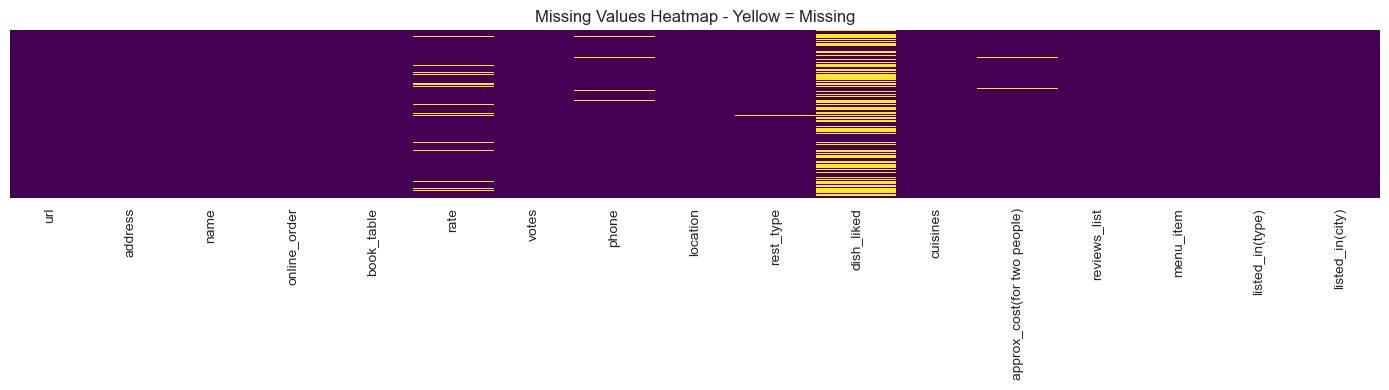

In [7]:
# Visualizing Missing Values
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap - Yellow = Missing')
plt.tight_layout()
plt.show()

In [8]:
# Checking duplicate values
dupes = df.duplicated().sum()
print(f"Duplicate rows : {dupes}")
print(f"As % of total  : {round(dupes / len(df) * 100, 2)}%")

Duplicate rows : 0
As % of total  : 0.0%


In [9]:
# Exposing Rate column problem
print("=== RATE — top 30 unique values ===")
print(df['rate'].value_counts().head(30))
print(f"\nTotal unique values in rate: {df['rate'].nunique()}")

=== RATE — top 30 unique values ===
rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1 /5    1474
4.1/5     1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
3.3 /5    1142
4.2/5     1019
3.2/5     1006
4.3 /5     917
3.2 /5     867
3.1/5      862
4.3/5      776
3.1 /5     699
4.4 /5     628
3.0/5      558
4.4/5      519
Name: count, dtype: int64

Total unique values in rate: 64


In [10]:
# Exposing approx_cost column problem
print("=== APPROX COST — top 20 unique values ===")
print(df['approx_cost(for two people)'].value_counts().head(20))

=== APPROX COST — top 20 unique values ===
approx_cost(for two people)
300      7576
400      6562
500      4980
200      4857
600      3714
250      2959
800      2285
150      2066
700      1948
350      1763
1,000    1637
450      1417
1,200     993
100       993
1,500     971
650       776
550       761
750       758
900       700
1,300     516
Name: count, dtype: int64


In [11]:
print(f"\nData type: {df['approx_cost(for two people)'].dtype}")


Data type: object


In [12]:
# Checking categorical columns
cols_to_check = ['online_order', 'book_table', 'listed_in(type)']

for col in cols_to_check:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())
    print(f"Nulls: {df[col].isnull().sum()}")


=== online_order ===
online_order
Yes    30444
No     21273
Name: count, dtype: int64
Nulls: 0

=== book_table ===
book_table
No     45268
Yes     6449
Name: count, dtype: int64
Nulls: 0

=== listed_in(type) ===
listed_in(type)
Delivery              25942
Dine-out              17779
Desserts               3593
Cafes                  1723
Drinks & nightlife     1101
Buffet                  882
Pubs and bars           697
Name: count, dtype: int64
Nulls: 0


In [13]:
# Top locations
print("=== TOP 20 LOCATIONS ===")
print(df['location'].value_counts().head(20))

=== TOP 20 LOCATIONS ===
location
BTM                      5124
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Indiranagar              2083
Jayanagar                1926
Marathahalli             1846
Bannerghatta Road        1630
Bellandur                1286
Electronic City          1258
Koramangala 1st Block    1238
Brigade Road             1218
Koramangala 7th Block    1181
Koramangala 6th Block    1156
Sarjapur Road            1065
Ulsoor                   1023
Koramangala 4th Block    1017
MG Road                   918
Banashankari              906
Name: count, dtype: int64


In [14]:
# Restraunt Types and cuisines
print("=== REST TYPE — top 15 ===")
print(df['rest_type'].value_counts().head(15))

print("\n=== CUISINES — top 15 (raw, not yet parsed) ===")
print(df['cuisines'].value_counts().head(15))

=== REST TYPE — top 15 ===
rest_type
Quick Bites           19132
Casual Dining         10330
Cafe                   3732
Delivery               2604
Dessert Parlor         2263
Takeaway, Delivery     2037
Casual Dining, Bar     1154
Bakery                 1141
Beverage Shop           867
Bar                     697
Food Court              624
Sweet Shop              468
Bar, Casual Dining      425
Lounge                  396
Pub                     357
Name: count, dtype: int64

=== CUISINES — top 15 (raw, not yet parsed) ===
cuisines
North Indian                           2913
North Indian, Chinese                  2385
South Indian                           1828
Biryani                                 918
Bakery, Desserts                        911
Fast Food                               803
Desserts                                766
Cafe                                    756
South Indian, North Indian, Chinese     726
Bakery                                  651
Chinese            

In [15]:
print("PHASE 1 COMPLETE — KEY FINDINGS")
print("-" * 45)

print("\n  DATASET")
print("  - 51,717 restaurants x 17 columns")
print("  - Source : Kaggle — Zomato Bangalore (Himanshu Poddar)")

print("\n  COLUMNS TO DROP IN PHASE 2")
print("  - url          : just a Zomato link, no analytical value")
print("  - address      : too granular, location column is sufficient")
print("  - phone        : not relevant to analysis")
print("  - reviews_list : complex nested strings, out of scope")
print("  - menu_item    : complex nested strings, out of scope")

print("\n  MISSING VALUES — STRATEGY")
print("  - dish_liked   : 28,078 rows (54.3%) — keep col, fill with 'Not Available'")
print("  - rate         :  7,775 rows (15.0%) — handle in fix step below")
print("  - approx_cost  :    346 rows  (0.7%) — drop these rows")
print("  - rest_type    :    227 rows  (0.4%) — drop these rows")
print("  - cuisines     :     45 rows  (0.1%) — drop these rows")
print("  - location     :     21 rows  (0.0%) — drop these rows")

print("\n  COLUMNS TO FIX IN PHASE 2")
print("  - rate         : TWO formats exist — '3.9/5' and '3.9 /5' (space before slash)")
print("                   'NEW' (2,208 rows) and '-' -> NaN, rest -> float")
print("  - approx_cost  : '1,200' -> remove comma -> int")
print("  - online_order : 'Yes'/'No' -> 1/0")
print("  - book_table   : 'Yes'/'No' -> 1/0")

print("\n  NEW COLUMNS TO CREATE IN PHASE 3")
print("  - price_category : budget / mid-range / premium  (from approx_cost)")
print("  - rating_label   : poor / average / good / excellent  (from rate)")
print("  - primary_cuisine: first cuisine extracted from cuisines column")

PHASE 1 COMPLETE — KEY FINDINGS
---------------------------------------------

  DATASET
  - 51,717 restaurants x 17 columns
  - Source : Kaggle — Zomato Bangalore (Himanshu Poddar)

  COLUMNS TO DROP IN PHASE 2
  - url          : just a Zomato link, no analytical value
  - address      : too granular, location column is sufficient
  - phone        : not relevant to analysis
  - reviews_list : complex nested strings, out of scope
  - menu_item    : complex nested strings, out of scope

  MISSING VALUES — STRATEGY
  - dish_liked   : 28,078 rows (54.3%) — keep col, fill with 'Not Available'
  - rate         :  7,775 rows (15.0%) — handle in fix step below
  - approx_cost  :    346 rows  (0.7%) — drop these rows
  - rest_type    :    227 rows  (0.4%) — drop these rows
  - cuisines     :     45 rows  (0.1%) — drop these rows
  - location     :     21 rows  (0.0%) — drop these rows

  COLUMNS TO FIX IN PHASE 2
  - rate         : TWO formats exist — '3.9/5' and '3.9 /5' (space before slash)


# Data Cleaning

This phase transforms the raw 51,717-row dataset into a clean,
analysis-ready version before feature engineering and EDA.

## Steps
1. Make a working copy of the raw dataframe
2. Drop 5 non-analytical columns
3. Rename 3 columns with awkward parentheses-based names
4. Fill dish_liked nulls (54.3% missing) -> 'Not Available'
5. Strip whitespace from all string columns
6. Fix `rate` — two formats + 'NEW'/'-' entries -> float
7. Fix `approx_cost` - remove commas -> int
8. Encode `online_order` and `book_table` -> binary (1/0)
9. Drop null rows in critical columns
10. Remove duplicate rows
11. Final verification

In [16]:
# Making a Working copy
df_clean = df.copy()

print(f"Raw df shape   : {df.shape}")
print(f"Clean df shape : {df_clean.shape}")
print("Working copy created!")

Raw df shape   : (51717, 17)
Clean df shape : (51717, 17)
Working copy created!


In [17]:
# Dropping non-Analytical columns
cols_to_drop = ['url', 'address', 'phone', 'reviews_list', 'menu_item']

df_clean.drop(columns=cols_to_drop, inplace=True)

print(f"Columns dropped : {len(cols_to_drop)}")
print(f"Columns remaining : {df_clean.shape[1]}")
print(f"\nRemaining columns:")
for i, col in enumerate(df_clean.columns.tolist(), 1):
    print(f"  {i:2}. {col}")

Columns dropped : 5
Columns remaining : 12

Remaining columns:
   1. name
   2. online_order
   3. book_table
   4. rate
   5. votes
   6. location
   7. rest_type
   8. dish_liked
   9. cuisines
  10. approx_cost(for two people)
  11. listed_in(type)
  12. listed_in(city)


In [18]:
# These parentheses-based names cause issues with dot notation
# Renaming them now saves pain in every cell going forward

df_clean.rename(columns={
    'approx_cost(for two people)' : 'approx_cost',
    'listed_in(type)'             : 'listed_type',
    'listed_in(city)'             : 'listed_city'
}, inplace=True)

print("Renamed columns:")
print("  approx_cost(for two people) -> approx_cost")
print("  listed_in(type)             -> listed_type")
print("  listed_in(city)             -> listed_city")
print(f"\nFull column list: {df_clean.columns.tolist()}")

Renamed columns:
  approx_cost(for two people) -> approx_cost
  listed_in(type)             -> listed_type
  listed_in(city)             -> listed_city

Full column list: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'listed_type', 'listed_city']


In [19]:
# dish_liked has 54.3% missing — don't drop these rows
# Fill with placeholder so the column stays usable

df_clean['dish_liked'] = df_clean['dish_liked'].fillna('Not Available')

print(f"dish_liked nulls remaining : {df_clean['dish_liked'].isnull().sum()}")
print(f"'Not Available' count      : {(df_clean['dish_liked'] == 'Not Available').sum():,}")

dish_liked nulls remaining : 0
'Not Available' count      : 28,078


In [20]:
# .str.strip() removes leading/trailing spaces only
# Important: "3.9 /5" still has the middle space after this
# That middle space is handled specifically in the rate fix (Cell 6)

str_cols = df_clean.select_dtypes(include='object').columns

for col in str_cols:
    df_clean[col] = df_clean[col].str.strip()

print(f"Whitespace stripped from {len(str_cols)} columns:")
print(f"  {list(str_cols)}")

Whitespace stripped from 11 columns:
  ['name', 'online_order', 'book_table', 'rate', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'listed_type', 'listed_city']


In [21]:
# Two formats exist simultaneously: "3.9/5" and "3.9 /5"
# Chain:
#   Step 1 - replace 'NEW' and '-' with NaN
#   Step 2 - remove ALL spaces (handles both formats in one shot)
#   Step 3 - split on '/' and keep left side
#   Step 4 - convert to float

df_clean['rate'] = (
    df_clean['rate']
    .replace({'NEW': np.nan, '-': np.nan})          
    .str.replace(' ', '', regex=False)             
    .str.split('/').str[0]                         
    .astype(float)                                  
)

print(f"rate dtype         : {df_clean['rate'].dtype}")
print(f"rate nulls (NEW/-) : {df_clean['rate'].isnull().sum():,}")
print(f"rate min           : {df_clean['rate'].min()}")
print(f"rate max           : {df_clean['rate'].max()}")
print(f"rate mean          : {df_clean['rate'].mean():.2f}")
print(f"\nSample cleaned values:")
print(df_clean['rate'].dropna().head(10).tolist())

rate dtype         : float64
rate nulls (NEW/-) : 10,052
rate min           : 1.8
rate max           : 4.9
rate mean          : 3.70

Sample cleaned values:
[4.1, 4.1, 3.8, 3.7, 3.8, 3.8, 3.6, 4.6, 4.0, 4.2]


In [22]:
# Values like "1,200" -> remove comma -> "1200" -> float
# (keeping as float for now because 346 nulls still exist)

df_clean['approx_cost'] = (
    df_clean['approx_cost']
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(f"approx_cost dtype : {df_clean['approx_cost'].dtype}")
print(f"approx_cost nulls : {df_clean['approx_cost'].isnull().sum()}")
print(f"approx_cost min   : ₹{df_clean['approx_cost'].min():.0f}")
print(f"approx_cost max   : ₹{df_clean['approx_cost'].max():.0f}")
print(f"approx_cost mean  : ₹{df_clean['approx_cost'].mean():.0f}")

approx_cost dtype : float64
approx_cost nulls : 346
approx_cost min   : ₹40
approx_cost max   : ₹6000
approx_cost mean  : ₹555


In [23]:
# Binary encode online_order and book_table
df_clean['online_order'] = df_clean['online_order'].map({'Yes': 1, 'No': 0})
df_clean['book_table']   = df_clean['book_table'].map({'Yes': 1, 'No': 0})

print("online_order distribution:")
print(df_clean['online_order'].value_counts().to_dict())
print(f"  -> {df_clean['online_order'].mean()*100:.1f}% of restaurants support online ordering")

print("\nbook_table distribution:")
print(df_clean['book_table'].value_counts().to_dict())
print(f"  -> {df_clean['book_table'].mean()*100:.1f}% of restaurants support table booking")

online_order distribution:
{1: 30444, 0: 21273}
  -> 58.9% of restaurants support online ordering

book_table distribution:
{0: 45268, 1: 6449}
  -> 12.5% of restaurants support table booking


In [24]:
# We drop rows only where columns we actively analyse have nulls
# rate nulls are KEPT — they represent 'NEW' restaurants (meaningful)

before = len(df_clean)

critical_cols = ['approx_cost', 'rest_type', 'cuisines', 'location']
df_clean.dropna(subset=critical_cols, inplace=True)

# Now approx_cost has no nulls — safe to convert to int
df_clean['approx_cost'] = df_clean['approx_cost'].astype(int)

after = len(df_clean)

print(f"Rows before  : {before:,}")
print(f"Rows dropped : {before - after:,}  ({round((before-after)/before*100, 2)}% of data)")
print(f"Rows after   : {after:,}")
print(f"\napprox_cost dtype now: {df_clean['approx_cost'].dtype}")

Rows before  : 51,717
Rows dropped : 569  (1.1% of data)
Rows after   : 51,148

approx_cost dtype now: int64


In [25]:
before = len(df_clean)

df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

after = len(df_clean)

print(f"Duplicate rows removed : {before - after:,}")
print(f"Final row count        : {after:,}")

Duplicate rows removed : 106
Final row count        : 51,042


In [26]:
print("=== CLEANED DATASET ===")

print(f"\n  Final shape   : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

print(f"\n  Data types:")
for col, dtype in df_clean.dtypes.items():
    print(f"    {col:<30} {dtype}")

print(f"\n  Missing values remaining:")
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("    None — except rate (NEW restaurants, intentional)")
else:
    for col, count in missing.items():
        print(f"    {col:<30} {count:,} ({round(count/len(df_clean)*100,2)}%)")

print(f"\n  approx_cost range : ₹{df_clean['approx_cost'].min()} — ₹{df_clean['approx_cost'].max()}")
print(f"  rate range        : {df_clean['rate'].min()} — {df_clean['rate'].max()}")
print(f"  online ordering   : {df_clean['online_order'].mean()*100:.1f}% of restaurants")
print(f"  table booking     : {df_clean['book_table'].mean()*100:.1f}% of restaurants")

=== CLEANED DATASET ===

  Final shape   : 51,042 rows x 12 columns

  Data types:
    name                           object
    online_order                   int64
    book_table                     int64
    rate                           float64
    votes                          int64
    location                       object
    rest_type                      object
    dish_liked                     object
    cuisines                       object
    approx_cost                    int64
    listed_type                    object
    listed_city                    object

  Missing values remaining:
    rate                           9,852 (19.3%)

  approx_cost range : ₹40 — ₹6000
  rate range        : 1.8 — 4.9
  online ordering   : 59.2% of restaurants
  table booking     : 12.6% of restaurants


In [27]:
# See the actual raw values to confirm what we're mapping
print("=== RAW online_order values ===")
print(df['online_order'].str.strip().value_counts())

print("\n=== RAW book_table values ===")
print(df['book_table'].str.strip().value_counts())

=== RAW online_order values ===
online_order
Yes    30444
No     21273
Name: count, dtype: int64

=== RAW book_table values ===
book_table
No     45268
Yes     6449
Name: count, dtype: int64


In [28]:
original_count = len(df_clean)

# Build a clean lookup from raw df (stripped to match df_clean)
lookup = df[['name', 'location', 'online_order', 'book_table']].copy()
lookup['name']         = lookup['name'].str.strip()
lookup['location']     = lookup['location'].str.strip()
lookup['online_order'] = lookup['online_order'].str.strip().map({'Yes': 1, 'No': 0})
lookup['book_table']   = lookup['book_table'].str.strip().map({'Yes': 1, 'No': 0})
lookup = lookup.drop_duplicates(subset=['name', 'location'], keep='first')

# Remove broken columns and merge corrected ones back
df_clean = df_clean.drop(columns=['online_order', 'book_table'])
df_clean = df_clean.merge(lookup, on=['name', 'location'], how='left')

# Fill any unmatched edge cases with 0, then convert to int
df_clean['online_order'] = df_clean['online_order'].fillna(0).astype(int)
df_clean['book_table']   = df_clean['book_table'].fillna(0).astype(int)

# Restore column order
df_clean = df_clean[['name', 'online_order', 'book_table', 'rate', 'votes',
                      'location', 'rest_type', 'dish_liked', 'cuisines',
                      'approx_cost', 'listed_type', 'listed_city']]

# Verify
print(f"Row count : {len(df_clean):,}  (was {original_count:,}) {'✓' if len(df_clean) == original_count else 'changed'}")
print(f"\nonline_order dtype : {df_clean['online_order'].dtype}")
print(f"online_order nulls : {df_clean['online_order'].isnull().sum()}")
print(f"online_order dist  : {df_clean['online_order'].value_counts().to_dict()}")
print(f"  -> {df_clean['online_order'].mean()*100:.1f}% of restaurants support online ordering")

print(f"\nbook_table dtype   : {df_clean['book_table'].dtype}")
print(f"book_table nulls   : {df_clean['book_table'].isnull().sum()}")
print(f"book_table dist    : {df_clean['book_table'].value_counts().to_dict()}")
print(f"  -> {df_clean['book_table'].mean()*100:.1f}% of restaurants support table booking")

Row count : 51,042  (was 51,042) ✓

online_order dtype : int64
online_order nulls : 0
online_order dist  : {1: 30874, 0: 20168}
  -> 60.5% of restaurants support online ordering

book_table dtype   : int64
book_table nulls   : 0
book_table dist    : {0: 44650, 1: 6392}
  -> 12.5% of restaurants support table booking


# Feature Engineering

This phase creates 4 new analytical columns derived from existing data.
No rows are added or removed — this is purely additive.

## New Columns

| Column           | Derived From   | Purpose                                          |
|------------------|----------------|--------------------------------------------------|
| `price_category` | `approx_cost`  | Segment restaurants into Budget / Mid / Premium  |
| `rating_label`   | `rate`         | Human-readable rating tier per restaurant        |
| `primary_cuisine`| `cuisines`     | First cuisine listed — main offering             |
| `cuisine_count`  | `cuisines`     | How many cuisines a restaurant offers            |

## Price Tier Logic (₹ for two people)
- **Budget**    : ₹0 – ₹400
- **Mid-range** : ₹401 – ₹800
- **Premium**   : ₹800+

## Rating Tier Logic
- **Poor**      : below 3.0
- **Average**   : 3.0 – 3.4
- **Good**      : 3.5 – 4.0
- **Excellent** : above 4.0
- **Unrated**   : NaN (NEW restaurants with no reviews yet)

In [29]:
# Price Category
price_bins   = [0, 400, 800, float('inf')]
price_labels = ['Budget', 'Mid-range', 'Premium']

df_clean['price_category'] = pd.cut(
    df_clean['approx_cost'],
    bins=price_bins,
    labels=price_labels,
    right=True
)

print("price_category distribution:")
counts = df_clean['price_category'].value_counts()
pcts   = (counts / len(df_clean) * 100).round(1)

for cat in price_labels:
    print(f"  {cat:<12} : {counts[cat]:>6,}  ({pcts[cat]}%)")

print(f"\napprox_cost stats by category:")
print(df_clean.groupby('price_category', observed=True)['approx_cost']
      .agg(['min', 'max', 'mean']).round(0))

price_category distribution:
  Budget       : 26,699  (52.3%)
  Mid-range    : 16,533  (32.4%)
  Premium      :  7,810  (15.3%)

approx_cost stats by category:
                min   max    mean
price_category                   
Budget           40   400   284.0
Mid-range       450   800   604.0
Premium         850  6000  1382.0


In [30]:
# Rating Label 
def assign_rating_label(r):
    if pd.isna(r):    return 'Unrated'
    elif r < 3.0:     return 'Poor'
    elif r < 3.5:     return 'Average'
    elif r <= 4.0:    return 'Good'
    else:             return 'Excellent'

df_clean['rating_label'] = df_clean['rate'].apply(assign_rating_label)

label_order = ['Excellent', 'Good', 'Average', 'Poor', 'Unrated']
counts = df_clean['rating_label'].value_counts()

print("rating_label distribution:")
for label in label_order:
    pct = round(counts[label] / len(df_clean) * 100, 1)
    print(f"  {label:<12} : {counts[label]:>6,}  ({pct}%)")

rating_label distribution:
  Excellent    :  9,126  (17.9%)
  Good         : 20,755  (40.7%)
  Average      :  9,094  (17.8%)
  Poor         :  2,215  (4.3%)
  Unrated      :  9,852  (19.3%)


In [31]:
# Primary Cuisine
# cuisines column contains comma-separated values like "North Indian, Chinese, Biryani"
# We extract just the first one as the restaurant's main offering

df_clean['primary_cuisine'] = (
    df_clean['cuisines']
    .str.split(',')
    .str[0]
    .str.strip()
)

print(f"Unique primary cuisines : {df_clean['primary_cuisine'].nunique()}")
print(f"\nTop 20 primary cuisines:")
top20 = df_clean['primary_cuisine'].value_counts().head(20)
for cuisine, count in top20.items():
    pct = round(count / len(df_clean) * 100, 1)
    print(f"  {cuisine:<30} : {count:>5,}  ({pct}%)")

Unique primary cuisines : 87

Top 20 primary cuisines:
  North Indian                   : 12,117  (23.7%)
  South Indian                   : 4,982  (9.8%)
  Cafe                           : 4,281  (8.4%)
  Chinese                        : 3,040  (6.0%)
  Biryani                        : 3,011  (5.9%)
  Fast Food                      : 2,559  (5.0%)
  Bakery                         : 2,157  (4.2%)
  Desserts                       : 2,124  (4.2%)
  Continental                    : 1,803  (3.5%)
  Beverages                      : 1,232  (2.4%)
  Andhra                         : 1,193  (2.3%)
  Ice Cream                      :   916  (1.8%)
  Kerala                         :   883  (1.7%)
  Street Food                    :   827  (1.6%)
  Mithai                         :   707  (1.4%)
  Finger Food                    :   691  (1.4%)
  Italian                        :   665  (1.3%)
  Pizza                          :   645  (1.3%)
  Arabian                        :   550  (1.1%)
  American  

In [32]:
# Cuisine Count
df_clean['cuisine_count'] = df_clean['cuisines'].str.split(',').str.len()

print("Cuisine count distribution (how many cuisines per restaurant):")
dist = df_clean['cuisine_count'].value_counts().sort_index()
for n, count in dist.items():
    pct = round(count / len(df_clean) * 100, 1)
    bar = '█' * int(pct / 2)
    print(f"  {n} cuisine{'s' if n > 1 else '':<2} : {count:>6,}  ({pct:>5}%)  {bar}")

print(f"\nAvg cuisines per restaurant : {df_clean['cuisine_count'].mean():.2f}")
print(f"Max cuisines in one entry   : {df_clean['cuisine_count'].max()}")

Cuisine count distribution (how many cuisines per restaurant):
  1 cuisine   : 12,205  ( 23.9%)  ███████████
  2 cuisines  : 17,704  ( 34.7%)  █████████████████
  3 cuisines  : 12,070  ( 23.6%)  ███████████
  4 cuisines  :  5,819  ( 11.4%)  █████
  5 cuisines  :  2,015  (  3.9%)  █
  6 cuisines  :    672  (  1.3%)  
  7 cuisines  :    367  (  0.7%)  
  8 cuisines  :    190  (  0.4%)  

Avg cuisines per restaurant : 2.45
Max cuisines in one entry   : 8


In [33]:
print("FEATURE ENGINEERING")
print("-" * 45)

print(f"\n  Shape : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

print(f"\n  All columns ({df_clean.shape[1]}):")
for i, col in enumerate(df_clean.columns, 1):
    dtype = str(df_clean[col].dtype)
    nulls = df_clean[col].isnull().sum()
    null_note = f"  <- {nulls:,} nulls (Unrated restaurants)" if col == 'rate' else ""
    print(f"  {i:>2}. {col:<20} {dtype:<10} {null_note}")

print(f"\n  NEW columns summary:")
print(f"  price_category  -> {dict(df_clean['price_category'].value_counts())}")
print(f"  rating_label    -> {dict(df_clean['rating_label'].value_counts())}")
print(f"  primary_cuisine -> {df_clean['primary_cuisine'].nunique()} unique cuisines")
print(f"  cuisine_count   -> avg {df_clean['cuisine_count'].mean():.1f} per restaurant")

FEATURE ENGINEERING
---------------------------------------------

  Shape : 51,042 rows x 16 columns

  All columns (16):
   1. name                 object     
   2. online_order         int64      
   3. book_table           int64      
   4. rate                 float64      <- 9,852 nulls (Unrated restaurants)
   5. votes                int64      
   6. location             object     
   7. rest_type            object     
   8. dish_liked           object     
   9. cuisines             object     
  10. approx_cost          int64      
  11. listed_type          object     
  12. listed_city          object     
  13. price_category       category   
  14. rating_label         object     
  15. primary_cuisine      object     
  16. cuisine_count        int64      

  NEW columns summary:
  price_category  -> {'Budget': 26699, 'Mid-range': 16533, 'Premium': 7810}
  rating_label    -> {'Good': 20755, 'Unrated': 9852, 'Excellent': 9126, 'Average': 9094, 'Poor': 2215}
  primary_c

# Exploratory Data Analysis (EDA)

Answers 7 core business questions using charts and aggregations.

## Questions Addressed
1. What does the rating landscape look like across Bengaluru?
2. How is pricing distributed — and do premium restaurants rate higher?
3. Which locations have the most restaurant activity?
4. Which cuisines dominate the Bengaluru food scene?
5. Does online ordering correlate with better ratings?
6. Which restaurant types are most common?
7. What numeric factors correlate most with higher ratings?

## Charts Produced
|  | Chart | Saved As |
|---|-------|----------|
| 1 | Rating distribution + label breakdown | 01_rating_analysis.png |
| 2 | Price category count + avg rating by tier | 02_price_analysis.png |
| 3 | Top 15 locations by count + avg rating | 03_location_analysis.png |
| 4 | Top 15 cuisines + avg rating by cuisine | 04_cuisine_analysis.png |
| 5 | Online order adoption + rating vs service | 05_services_analysis.png |
| 6 | Top 10 restaurant types | 06_rest_type_analysis.png |
| 7 | Correlation heatmap — all numeric features | 07_correlation_heatmap.png |

In [34]:
# Creating charts directory
import os
os.makedirs('charts', exist_ok=True)
print("charts/ directory ready!")

charts/ directory ready!


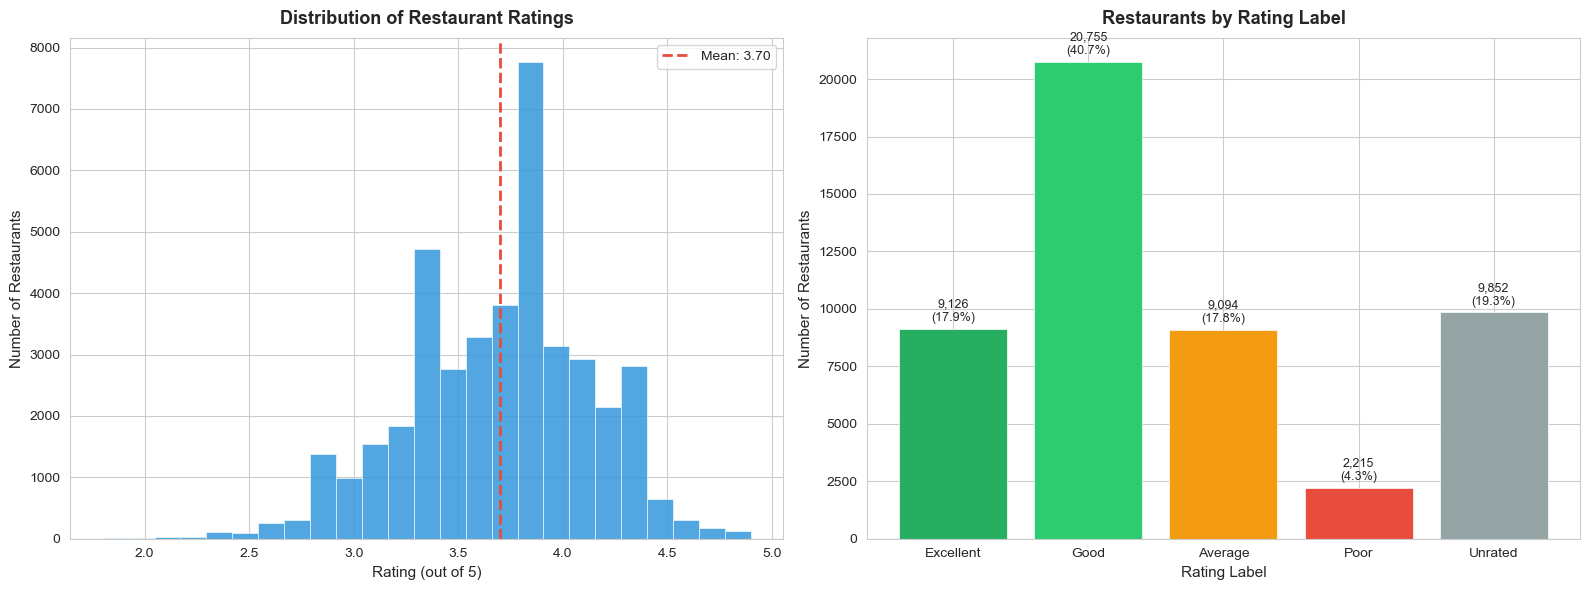

Mean rating          : 3.70 / 5.0
Rated 3.5 or above   : 72.5% of rated restaurants
Unrated restaurants  : 9,852 (new listings with no reviews)


In [35]:
# RATING ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Histogram of ratings (rated restaurants only)
rated_df  = df_clean.dropna(subset=['rate'])
mean_rate = rated_df['rate'].mean()

axes[0].hist(rated_df['rate'], bins=25, color='#3498db',
             edgecolor='white', linewidth=0.5, alpha=0.85)
axes[0].axvline(mean_rate, color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Mean: {mean_rate:.2f}')
axes[0].set_title('Distribution of Restaurant Ratings', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Rating (out of 5)', fontsize=11)
axes[0].set_ylabel('Number of Restaurants', fontsize=11)
axes[0].legend(fontsize=10)

# Right: Rating label bar chart
label_order  = ['Excellent', 'Good', 'Average', 'Poor', 'Unrated']
label_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
label_counts = df_clean['rating_label'].value_counts()
counts_ord   = [label_counts.get(l, 0) for l in label_order]

bars = axes[1].bar(label_order, counts_ord, color=label_colors,
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('Restaurants by Rating Label', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Rating Label', fontsize=11)
axes[1].set_ylabel('Number of Restaurants', fontsize=11)

for bar, count in zip(bars, counts_ord):
    pct = count / len(df_clean) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('charts/01_rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

above_35 = (rated_df['rate'] >= 3.5).sum() / len(rated_df) * 100
print(f"Mean rating          : {mean_rate:.2f} / 5.0")
print(f"Rated 3.5 or above   : {above_35:.1f}% of rated restaurants")
print(f"Unrated restaurants  : {label_counts.get('Unrated', 0):,} (new listings with no reviews)")

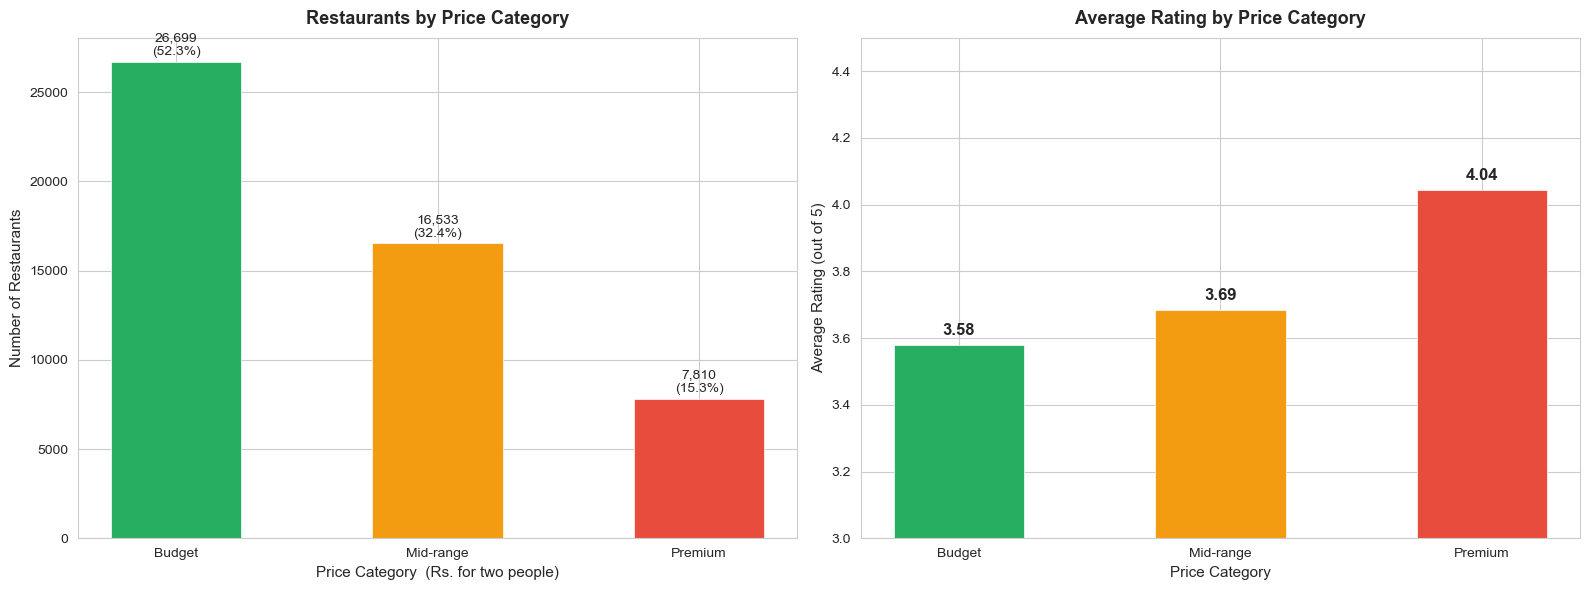

Average cost for two : Rs.556
Median cost for two  : Rs.400
Cost range           : Rs. 40 — 6000


In [36]:
# PRICE AND COST ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_order  = ['Budget', 'Mid-range', 'Premium']
cat_colors = ['#27ae60', '#f39c12', '#e74c3c']
cat_counts = df_clean['price_category'].value_counts()
counts_ord = [cat_counts.get(c, 0) for c in cat_order]

# Left: Price category count
bars1 = axes[0].bar(cat_order, counts_ord, color=cat_colors,
                    edgecolor='white', linewidth=0.5, width=0.5)
axes[0].set_title('Restaurants by Price Category', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Price Category  (Rs. for two people)', fontsize=11)
axes[0].set_ylabel('Number of Restaurants', fontsize=11)

for bar, count in zip(bars1, counts_ord):
    pct = count / len(df_clean) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

# Right: Avg rating by price category
avg_by_price = (df_clean.groupby('price_category', observed=True)['rate']
                .mean()
                .reindex(cat_order))

bars2 = axes[1].bar(cat_order, avg_by_price.values, color=cat_colors,
                    edgecolor='white', linewidth=0.5, width=0.5)
axes[1].set_title('Average Rating by Price Category', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Price Category', fontsize=11)
axes[1].set_ylabel('Average Rating (out of 5)', fontsize=11)
axes[1].set_ylim(3.0, 4.5)

for bar, val in zip(bars2, avg_by_price.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/02_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average cost for two : Rs.{df_clean['approx_cost'].mean():.0f}")
print(f"Median cost for two  : Rs.{df_clean['approx_cost'].median():.0f}")
print(f"Cost range           : Rs. {df_clean['approx_cost'].min()} — {df_clean['approx_cost'].max()}")

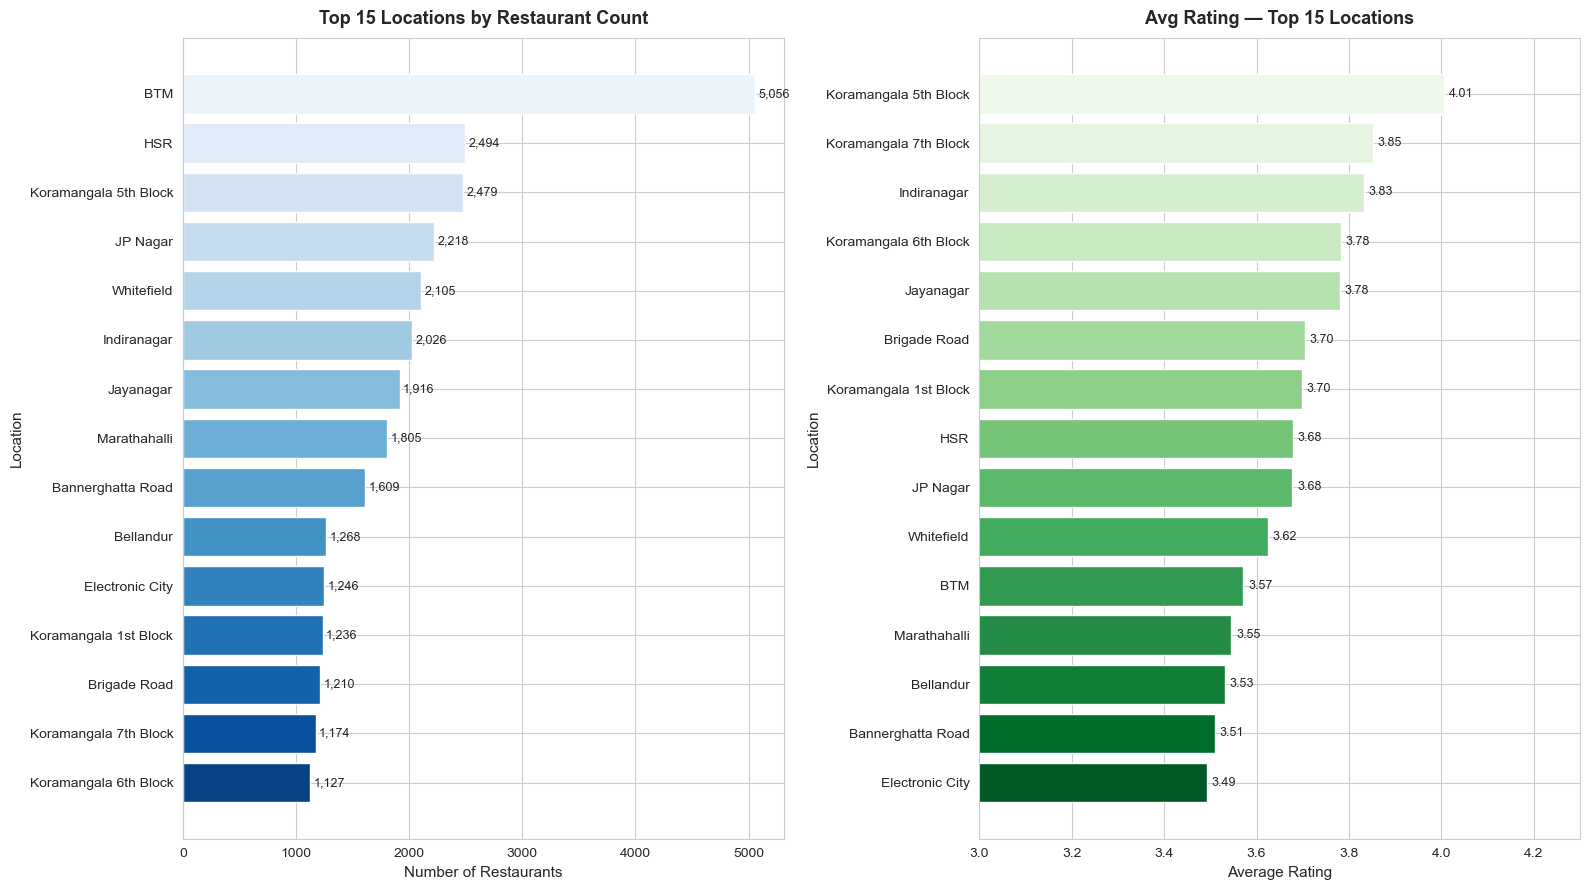

Total unique locations  : 93
Top location            : BTM  (5,056 restaurants)
Best rated (top 15)     : Koramangala 5th Block  (avg 4.01)
Lowest rated (top 15)   : Electronic City  (avg 3.49)


In [37]:
# LOCATION ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left: Top 15 locations by count
top15_loc = df_clean['location'].value_counts().head(15)

axes[0].barh(top15_loc.index[::-1], top15_loc.values[::-1],
             color=sns.color_palette('Blues_r', 15), edgecolor='white')
axes[0].set_title('Top 15 Locations by Restaurant Count', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Restaurants', fontsize=11)
axes[0].set_ylabel('Location', fontsize=11)
for i, (loc, count) in enumerate(zip(top15_loc.index[::-1], top15_loc.values[::-1])):
    axes[0].text(count + 30, i, f'{count:,}', va='center', fontsize=9)

# Right: Avg rating for those same 15 locations
# Filter to locations with 100+ restaurants to avoid noise
loc_counts    = df_clean['location'].value_counts()
active_locs   = loc_counts[loc_counts >= 100].index.tolist()
top15_names   = [l for l in top15_loc.index if l in active_locs]

avg_by_loc = (df_clean[df_clean['location'].isin(top15_names)]
              .groupby('location')['rate']
              .mean()
              .reindex(top15_names)
              .sort_values(ascending=True))

axes[1].barh(avg_by_loc.index, avg_by_loc.values,
             color=sns.color_palette('Greens_r', len(avg_by_loc)), edgecolor='white')
axes[1].set_title('Avg Rating — Top 15 Locations', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Average Rating', fontsize=11)
axes[1].set_ylabel('Location', fontsize=11)
axes[1].set_xlim(3.0, 4.3)
for i, val in enumerate(avg_by_loc.values):
    axes[1].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/03_location_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total unique locations  : {df_clean['location'].nunique()}")
print(f"Top location            : {top15_loc.index[0]}  ({top15_loc.values[0]:,} restaurants)")
print(f"Best rated (top 15)     : {avg_by_loc.index[-1]}  (avg {avg_by_loc.values[-1]:.2f})")
print(f"Lowest rated (top 15)   : {avg_by_loc.index[0]}  (avg {avg_by_loc.values[0]:.2f})")

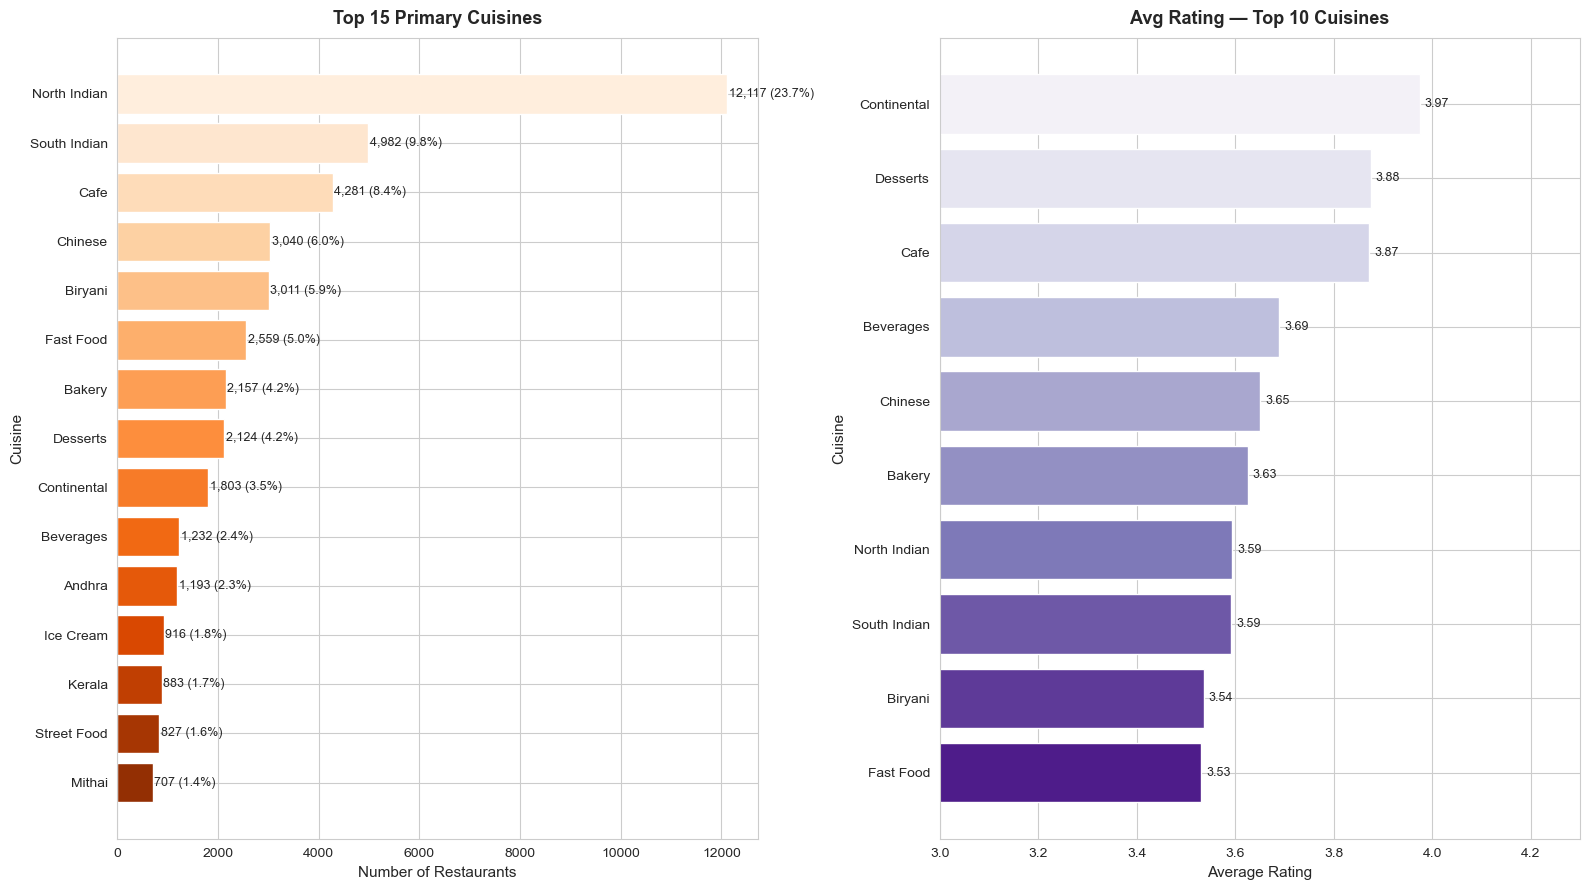

Unique primary cuisines  : 87
Top cuisine              : North Indian  (12,117 restaurants)
Top 3 cuisines cover     : 41.9% of all restaurants


In [38]:
# CUISINE ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left: Top 15 primary cuisines
top15_cuisine = df_clean['primary_cuisine'].value_counts().head(15)

axes[0].barh(top15_cuisine.index[::-1], top15_cuisine.values[::-1],
             color=sns.color_palette('Oranges_r', 15), edgecolor='white')
axes[0].set_title('Top 15 Primary Cuisines', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Number of Restaurants', fontsize=11)
axes[0].set_ylabel('Cuisine', fontsize=11)
for i, count in enumerate(top15_cuisine.values[::-1]):
    pct = count / len(df_clean) * 100
    axes[0].text(count + 30, i, f'{count:,} ({pct:.1f}%)', va='center', fontsize=9)

# Right: Avg rating — top 10 cuisines only (cleaner)
top10_names = top15_cuisine.index[:10].tolist()
avg_by_cuisine = (df_clean[df_clean['primary_cuisine'].isin(top10_names)]
                  .groupby('primary_cuisine')['rate']
                  .mean()
                  .sort_values(ascending=True))

axes[1].barh(avg_by_cuisine.index, avg_by_cuisine.values,
             color=sns.color_palette('Purples_r', 10), edgecolor='white')
axes[1].set_title('Avg Rating — Top 10 Cuisines', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Average Rating', fontsize=11)
axes[1].set_ylabel('Cuisine', fontsize=11)
axes[1].set_xlim(3.0, 4.3)
for i, val in enumerate(avg_by_cuisine.values):
    axes[1].text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/04_cuisine_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique primary cuisines  : {df_clean['primary_cuisine'].nunique()}")
print(f"Top cuisine              : {top15_cuisine.index[0]}  ({top15_cuisine.values[0]:,} restaurants)")
print(f"Top 3 cuisines cover     : {top15_cuisine.values[:3].sum()/len(df_clean)*100:.1f}% of all restaurants")

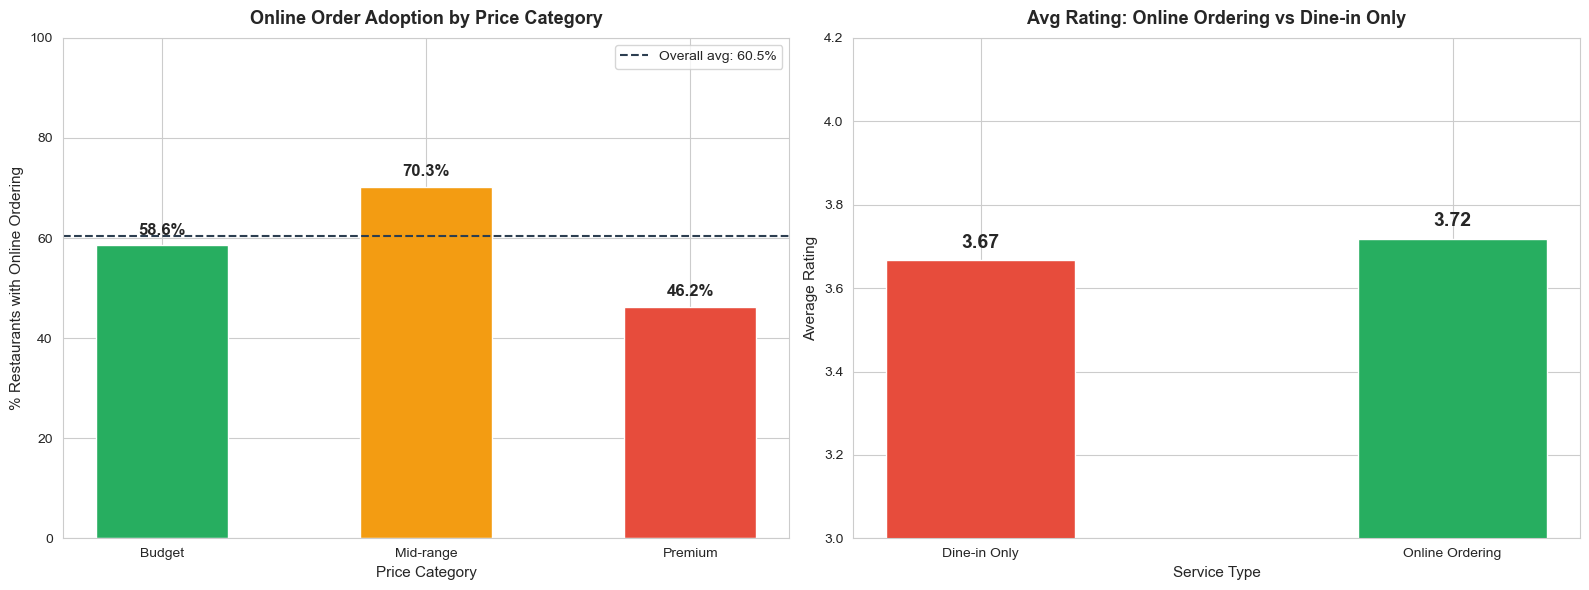

Online ordering restaurants rate 0.05 points higher on average
Adoption by tier — Budget: 58.6%  |  Mid: 70.3%  |  Premium: 46.2%


In [39]:
# SERVICE ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Online order adoption % by price category
online_by_price = (df_clean.groupby('price_category', observed=True)['online_order']
                   .mean() * 100).reindex(['Budget', 'Mid-range', 'Premium'])
overall_online  = df_clean['online_order'].mean() * 100

cat_colors = ['#27ae60', '#f39c12', '#e74c3c']
bars1 = axes[0].bar(online_by_price.index, online_by_price.values,
                    color=cat_colors, edgecolor='white', width=0.5)
axes[0].axhline(overall_online, color='#2c3e50', linestyle='--',
                linewidth=1.5, label=f'Overall avg: {overall_online:.1f}%')
axes[0].set_title('Online Order Adoption by Price Category', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Price Category', fontsize=11)
axes[0].set_ylabel('% Restaurants with Online Ordering', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=10)
for bar, val in zip(bars1, online_by_price.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right: Avg rating — online order (1) vs dine-in only (0)
avg_by_online = df_clean.groupby('online_order')['rate'].mean()
service_labels = ['Dine-in Only', 'Online Ordering']
service_colors = ['#e74c3c', '#27ae60']
service_vals   = [avg_by_online[0], avg_by_online[1]]

bars2 = axes[1].bar(service_labels, service_vals,
                    color=service_colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Rating: Online Ordering vs Dine-in Only', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Service Type', fontsize=11)
axes[1].set_ylabel('Average Rating', fontsize=11)
axes[1].set_ylim(3.0, 4.2)
for bar, val in zip(bars2, service_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/05_services_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

diff = avg_by_online[1] - avg_by_online[0]
print(f"Online ordering restaurants rate {abs(diff):.2f} points {'higher' if diff > 0 else 'lower'} on average")
print(f"Adoption by tier — Budget: {online_by_price['Budget']:.1f}%  |  Mid: {online_by_price['Mid-range']:.1f}%  |  Premium: {online_by_price['Premium']:.1f}%")

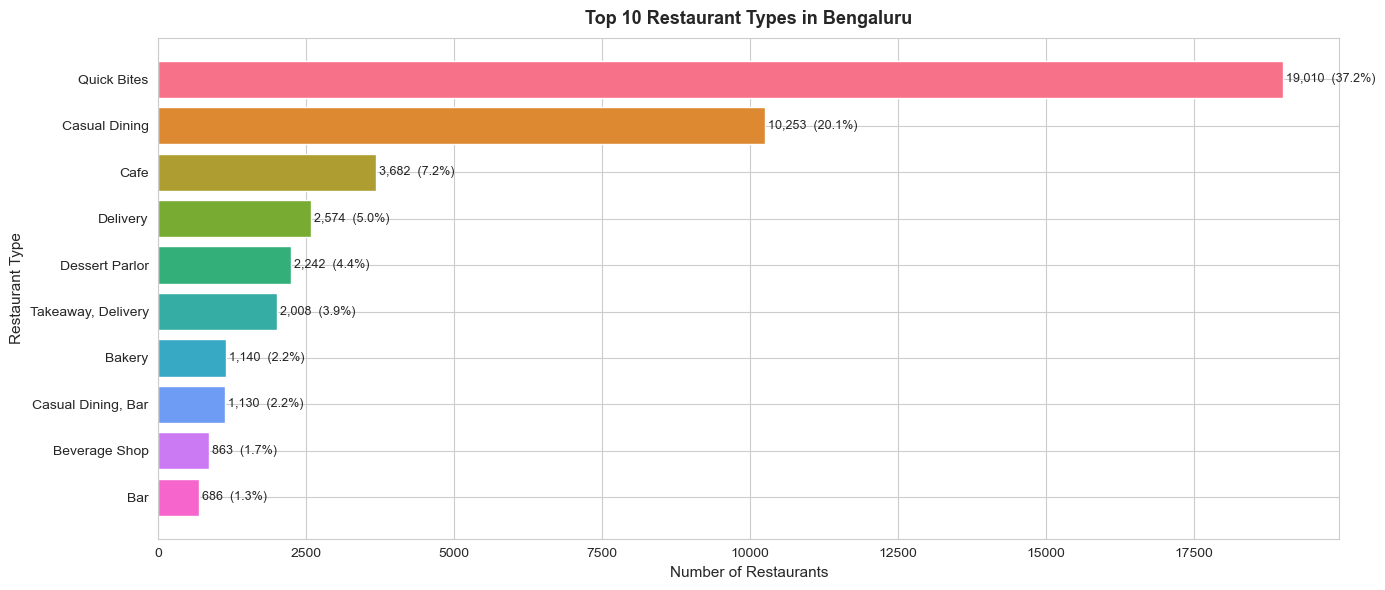

Most common type : Quick Bites  (19,010 restaurants, 37.2%)
Top 3 types cover: 64.5% of all restaurants


In [40]:
# RESTRAUNT TYPE ANALYSIS
top10_rest = df_clean['rest_type'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 6))
colors_rest = sns.color_palette('husl', 10)

ax.barh(top10_rest.index[::-1], top10_rest.values[::-1],
        color=colors_rest[::-1], edgecolor='white')
ax.set_title('Top 10 Restaurant Types in Bengaluru', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Number of Restaurants', fontsize=11)
ax.set_ylabel('Restaurant Type', fontsize=11)

for i, (rt, count) in enumerate(zip(top10_rest.index[::-1], top10_rest.values[::-1])):
    pct = count / len(df_clean) * 100
    ax.text(count + 50, i, f'{count:,}  ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/06_rest_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most common type : {top10_rest.index[0]}  ({top10_rest.values[0]:,} restaurants, {top10_rest.values[0]/len(df_clean)*100:.1f}%)")
print(f"Top 3 types cover: {top10_rest.values[:3].sum()/len(df_clean)*100:.1f}% of all restaurants")

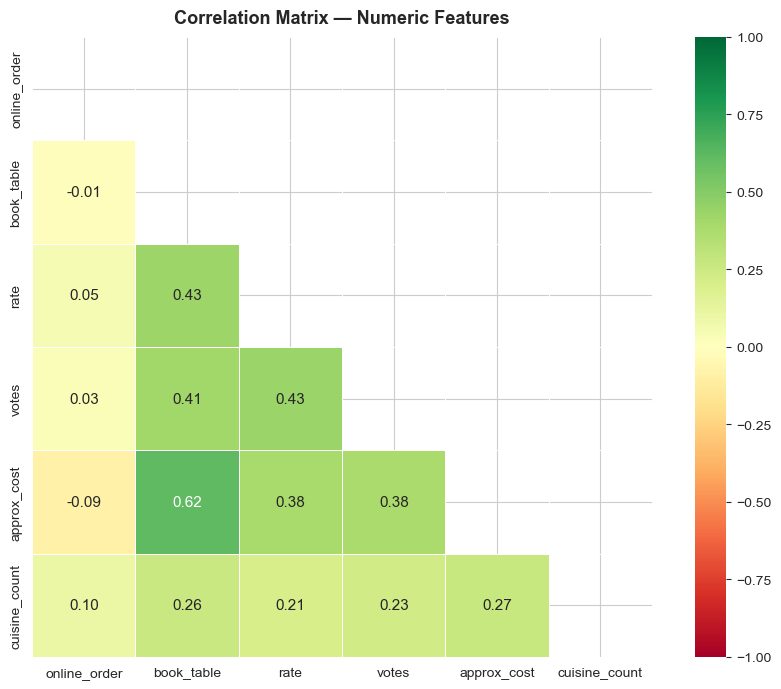

Correlations with 'rate' (strongest first):
  votes                :  0.435   positive ↑  (strong)
  book_table           :  0.425   positive ↑  (strong)
  approx_cost          :  0.384   positive ↑  (strong)
  cuisine_count        :  0.206   positive ↑  (moderate)
  online_order         :  0.054   positive ↑  (weak)


In [41]:
# CORRELATION HEATMAP
numeric_cols = ['online_order', 'book_table', 'rate', 'votes', 'approx_cost', 'cuisine_count']
corr_matrix  = df_clean[numeric_cols].corr()

# Lower triangle only (cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, mask=mask,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('charts/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with 'rate' (strongest first):")
rate_corr = corr_matrix['rate'].drop('rate').sort_values(key=abs, ascending=False)
for col, val in rate_corr.items():
    direction = 'positive ↑' if val > 0 else 'negative ↓'
    strength  = 'strong' if abs(val) > 0.3 else 'moderate' if abs(val) > 0.1 else 'weak'
    print(f"  {col:<20} : {val:>6.3f}   {direction}  ({strength})")

In [42]:
# KEY INSIGHTS AND SUMMARY OF EDA
rated_df       = df_clean.dropna(subset=['rate'])
top_location   = df_clean['location'].value_counts().index[0]
top_cuisine    = df_clean['primary_cuisine'].value_counts().index[0]
top_rest_type  = df_clean['rest_type'].value_counts().index[0]
best_rated_loc = (df_clean[df_clean['location'].map(df_clean['location'].value_counts()) >= 100]
                  .groupby('location')['rate'].mean().idxmax())
online_avg     = df_clean.groupby('online_order')['rate'].mean()

print("KEY INSIGHTS")
print("-" * 50)

print("\n  RATINGS")
print(f"  - Mean rating         : {rated_df['rate'].mean():.2f} / 5.0")
print(f"  - Rated 3.5+          : {(rated_df['rate']>=3.5).sum()/len(rated_df)*100:.1f}% of rated restaurants")
print(f"  - Poor rated (<3.0)   : {(rated_df['rate']<3.0).sum()/len(rated_df)*100:.1f}% of rated restaurants")
print(f"  - Unrated (NEW)       : {(df_clean['rating_label']=='Unrated').sum():,} restaurants")

print("\n  PRICING")
print(f"  - Budget (≤₹400)       : {(df_clean['price_category']=='Budget').sum():,} ({(df_clean['price_category']=='Budget').sum()/len(df_clean)*100:.1f}%)")
print(f"  - Mid-range (₹401-800) : {(df_clean['price_category']=='Mid-range').sum():,} ({(df_clean['price_category']=='Mid-range').sum()/len(df_clean)*100:.1f}%)")
print(f"  - Premium (₹800+)      : {(df_clean['price_category']=='Premium').sum():,} ({(df_clean['price_category']=='Premium').sum()/len(df_clean)*100:.1f}%)")
print(f"  - Average cost for two : ₹{df_clean['approx_cost'].mean():.0f}")

print("\n  LOCATIONS")
print(f"  - Total locations     : {df_clean['location'].nunique()}")
print(f"  - Top by count        : {top_location}  ({df_clean['location'].value_counts().values[0]:,} restaurants)")
print(f"  - Best rated area     : {best_rated_loc}  (avg {df_clean[df_clean['location']==best_rated_loc]['rate'].mean():.2f})")

print("\n  CUISINES & TYPES")
print(f"  - Unique cuisines     : {df_clean['primary_cuisine'].nunique()}")
print(f"  - Top cuisine         : {top_cuisine}  ({df_clean['primary_cuisine'].value_counts().values[0]:,} restaurants)")
print(f"  - Top restaurant type : {top_rest_type}  ({df_clean['rest_type'].value_counts().values[0]:,})")
print(f"  - Avg cuisines/resto  : {df_clean['cuisine_count'].mean():.1f}")

print("\n  SERVICES")
print(f"  - Online ordering     : {df_clean['online_order'].mean()*100:.1f}% of restaurants")
print(f"  - Table booking       : {df_clean['book_table'].mean()*100:.1f}% of restaurants")
print(f"  - Online avg rating   : {online_avg[1]:.2f}  vs  Dine-in avg: {online_avg[0]:.2f}")

print("\n  7 charts saved to charts/ folder")

KEY INSIGHTS
--------------------------------------------------

  RATINGS
  - Mean rating         : 3.70 / 5.0
  - Rated 3.5+          : 72.5% of rated restaurants
  - Poor rated (<3.0)   : 5.4% of rated restaurants
  - Unrated (NEW)       : 9,852 restaurants

  PRICING
  - Budget (≤₹400)       : 26,699 (52.3%)
  - Mid-range (₹401-800) : 16,533 (32.4%)
  - Premium (₹800+)      : 7,810 (15.3%)
  - Average cost for two : ₹556

  LOCATIONS
  - Total locations     : 93
  - Top by count        : BTM  (5,056 restaurants)
  - Best rated area     : Lavelle Road  (avg 4.14)

  CUISINES & TYPES
  - Unique cuisines     : 87
  - Top cuisine         : North Indian  (12,117 restaurants)
  - Top restaurant type : Quick Bites  (19,010)
  - Avg cuisines/resto  : 2.5

  SERVICES
  - Online ordering     : 60.5% of restaurants
  - Table booking       : 12.5% of restaurants
  - Online avg rating   : 3.72  vs  Dine-in avg: 3.67

  7 charts saved to charts/ folder


# Export & Handoff

Exports the final cleaned and feature-engineered dataset to CSV
for ingestion into PostgreSQL (Layer 2).

## Final Dataset Specs
- Rows    : 51,042
- Columns : 16
- Output  : zomato_cleaned.csv

In [43]:
print("Final column list before export:")
for i, (col, dtype) in enumerate(df_clean.dtypes.items(), 1):
    null_count = df_clean[col].isnull().sum()
    null_note  = f"  <- {null_count:,} nulls (Unrated)" if null_count > 0 else ""
    print(f"  {i:>2}. {col:<22} {str(dtype):<12} {null_note}")

print(f"\nShape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Memory : {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Final column list before export:
   1. name                   object       
   2. online_order           int64        
   3. book_table             int64        
   4. rate                   float64        <- 9,852 nulls (Unrated)
   5. votes                  int64        
   6. location               object       
   7. rest_type              object       
   8. dish_liked             object       
   9. cuisines               object       
  10. approx_cost            int64        
  11. listed_type            object       
  12. listed_city            object       
  13. price_category         category     
  14. rating_label           object       
  15. primary_cuisine        object       
  16. cuisine_count          int64        

Shape  : 51,042 rows × 16 columns
Memory : 30.5 MB


In [44]:
# Export to CSV
export_path = 'zomato_cleaned.csv'

df_clean.to_csv(export_path, index=False, encoding='utf-8-sig')

# Verify the file was written correctly
df_verify = pd.read_csv(export_path, encoding='utf-8-sig')

print(f"Exported to      : {export_path}")
print(f"Rows written     : {df_verify.shape[0]:,}")
print(f"Columns written  : {df_verify.shape[1]}")
print(f"\nColumn names in CSV:")
print(list(df_verify.columns))

# Sanity check — first 3 rows
print(f"\nFirst 3 rows of exported file:")
print(df_verify.head(3).to_string())

Exported to      : zomato_cleaned.csv
Rows written     : 51,042
Columns written  : 16

Column names in CSV:
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost', 'listed_type', 'listed_city', 'price_category', 'rating_label', 'primary_cuisine', 'cuisine_count']

First 3 rows of exported file:
              name  online_order  book_table  rate  votes      location            rest_type                                                                                            dish_liked                        cuisines  approx_cost listed_type   listed_city price_category rating_label primary_cuisine  cuisine_count
0            Jalsa             1           1   4.1    775  Banashankari        Casual Dining        Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup  North Indian, Mughlai, Chinese          800      Buffet  Banashankari      Mid-range    Excellent    North Indian    

In [45]:
# price_category is pandas Categorical dtype
# SQLAlchemy cannot map Categorical to PostgreSQL — must convert to string first

df_clean['price_category'] = df_clean['price_category'].astype(str)

print("Dtypes ready for SQL push:")
for col, dtype in df_clean.dtypes.items():
    print(f"  {col:<22} {dtype}")

Dtypes ready for SQL push:
  name                   object
  online_order           int64
  book_table             int64
  rate                   float64
  votes                  int64
  location               object
  rest_type              object
  dish_liked             object
  cuisines               object
  approx_cost            int64
  listed_type            object
  listed_city            object
  price_category         object
  rating_label           object
  primary_cuisine        object
  cuisine_count          int64


In [46]:
# Connecting to postgreSQL
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

host     = os.getenv("DB_HOST")
port     = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
user     = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql://{user}:{password}@{host}:{port}/{database}"
)

with engine.connect() as conn:
    print(f"Connected to PostgreSQL successfully!")
    print(f"Database : {database}")

Connected to PostgreSQL successfully!
Database : zomato_restaurants


In [47]:
df_clean.to_sql(
    'zomato_restaurants',   # table name
    engine,
    if_exists='replace',    # drop and recreate if exists
    index=False,
    method='multi',
    chunksize=5000
)

print("Data pushed successfully!")
print(f"  Table   : zomato_restaurants")
print(f"  Rows    : {len(df_clean):,}")
print(f"  Columns : {df_clean.shape[1]}")

Data pushed successfully!
  Table   : zomato_restaurants
  Rows    : 51,042
  Columns : 16


In [48]:
import pandas as pd

verify_query = """
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT location)        AS unique_locations,
        COUNT(DISTINCT primary_cuisine) AS unique_cuisines,
        ROUND(AVG(rate)::numeric, 2)    AS avg_rating,
        MIN(approx_cost)                AS min_cost,
        MAX(approx_cost)                AS max_cost
    FROM zomato_restaurants;
"""

with engine.connect() as conn:
    result = pd.read_sql(verify_query, conn)

print("=== PostgreSQL Verification ===")
print(result.to_string(index=False))
print("\nPostgreSQL layer ready!")
print("Next -> write business queries in pgAdmin")

=== PostgreSQL Verification ===
 total_rows  unique_locations  unique_cuisines  avg_rating  min_cost  max_cost
      51042                93               87         3.7        40      6000

PostgreSQL layer ready!
Next -> write business queries in pgAdmin


## Entity-Level Deduplication (Post-Validation Fix)
discovered by cross-validating Tableau aggregates against SQL outputs (SUM(votes) ≈ 6× the SQL value for the same restaurant).

## Entity-Level Deduplication
  Row-level duplicate check returned 0, but cross-validating Tableau
  aggregates against SQL outputs revealed entity-level duplication:
  each restaurant appears once per listing category (~6 rows per
  restaurant). Counts at listing grain overstate restaurant counts ~6x.
  Fix: export a second table at restaurant grain (one row per
  name+location, highest-votes snapshot), keeping zomato_cleaned.csv
  for category-level analysis.

In [50]:
# Evidence: entity-level duplication in the exported dataset
zc = pd.read_csv('zomato_cleaned.csv')

print("Row-level dupes :", zc.duplicated().sum())
print("Entity-level    :", zc.duplicated(subset=['name','location']).sum())
zc[zc['name'] == 'Byg Brewski Brewing Company'][
    ['name','location','listed_type','votes','rate']]

Row-level dupes : 0
Entity-level    : 39005


,name,location,listed_type,votes,rate
3896,Byg Brewski Brewing Company,Sarjapur Road,Delivery,16345,4.9
4763,Byg Brewski Brewing Company,Sarjapur Road,Dine-out,16345,4.9
4904,Byg Brewski Brewing Company,Sarjapur Road,Drinks & nightlife,16345,4.9
48546,Byg Brewski Brewing Company,Sarjapur Road,Delivery,16832,4.9
48993,Byg Brewski Brewing Company,Sarjapur Road,Dine-out,16832,4.9
49417,Byg Brewski Brewing Company,Sarjapur Road,Drinks & nightlife,16832,4.9


In [ ]:
%run dedupe_restaurants.py

In [51]:
ru = pd.read_csv('restaurants_unique.csv')
print(ru.shape)
ru[ru['name'].isin(['Byg Brewski Brewing Company','Toit','Truffles'])]

(12037, 15)


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost,listed_city,price_category,rating_label,primary_cuisine,cuisine_count
1787,Byg Brewski Brewing Company,1,1,4.9,16832,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600,Sarjapur Road,Premium,Excellent,Continental,5
11294,Toit,0,0,4.7,14956,Indiranagar,Microbrewery,"Beer, Pesto Pizza, Nachos, Cocktails, Beef Las...","Italian, American, Pizza",1500,Indiranagar,Premium,Excellent,Italian,3
11339,Truffles,0,0,4.6,1313,Indiranagar,"Cafe, Casual Dining","Burgers, Pasta, Crunchy Veg Burger, American C...","Cafe, American, Burger, Steak",900,Indiranagar,Premium,Excellent,Cafe,4
11340,Truffles,0,0,4.5,1239,Kalyan Nagar,"Cafe, Casual Dining","Burgers, Orange Mojito, Pasta, Ferrero Rocher ...","Cafe, American, Burger, Steak",900,Kammanahalli,Premium,Excellent,Cafe,4
11341,Truffles,0,0,4.7,14726,Koramangala 5th Block,"Cafe, Casual Dining","Burgers, Pasta, Cocktails, American Cheese Bur...","Cafe, American, Burger, Steak",900,Koramangala 7th Block,Premium,Excellent,Cafe,4
11342,Truffles,0,0,4.7,3916,New BEL Road,"Cafe, Casual Dining","Burgers, Pasta Arrabiata, Ferrero Rocher Milks...","Cafe, American, Burger, Steak",900,New BEL Road,Premium,Excellent,Cafe,4
11343,Truffles,0,0,4.5,3614,St. Marks Road,Cafe,"Burgers, Pasta, Cheese Burger, Potato Mash, Mo...","Cafe, American, Burger, Steak",900,Brigade Road,Premium,Excellent,Cafe,4
